In [ ]:
#load data
import pandas as pd
data = pd.read_csv("/content/train_loan.csv")
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
data.Credit_History.dtype

dtype('float64')

In [ ]:
#check info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


##a. Missing value handling


In [ ]:
#check duplicate values
data.duplicated().sum()

np.int64(0)

In [ ]:
#check null values
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
#drop loan id column
data.drop("Loan_ID",axis=1,inplace=True)
data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
#handle missing values
#create a function to handle missing values
def handle_missing_values(data):
    for col in data.columns:
        if data[col].dtype in ["int64", "float64"]:
            data[col] = data[col].fillna(data[col].median())
        else:
            data[col] = data[col].fillna(data[col].mode()[0])

    return data


In [ ]:
#call function
handle_missing_values(data)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
data.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


##b. Outlier detection

<Figure size 1500x1000 with 0 Axes>

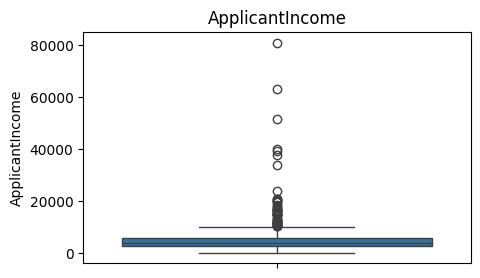

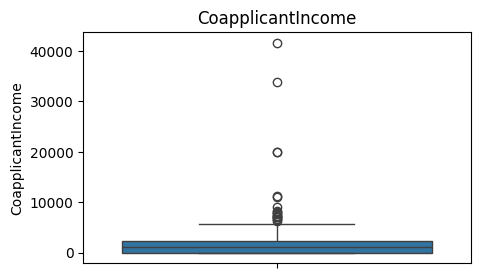

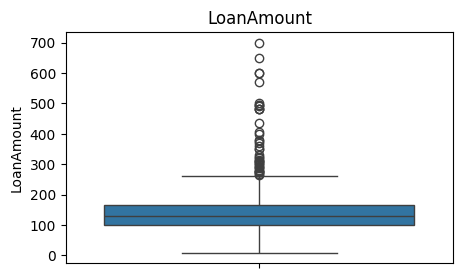

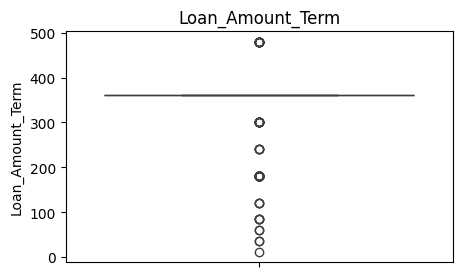

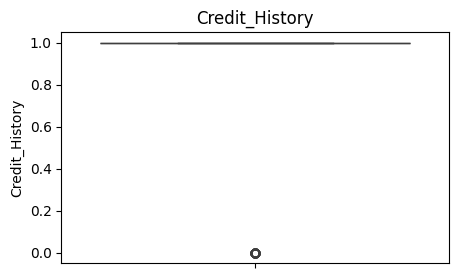

In [ ]:
#draw boxplot to find any outliers
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,10))
num_cols = data.select_dtypes("number").columns
for col in num_cols:
  plt.figure(figsize=(5,3))
  sns.boxplot(data[col])
  plt.title(col)
  plt.show()

In [ ]:
#function to handle outliers
def cap_outliers_numeric(df, numeric_cols):
    """
    Caps outliers in all numeric columns using 1.5*IQR method.
    Modifies the DataFrame in-place to avoid SettingWithCopyWarning.
    """
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Use .loc to modify safely
        df.loc[:, col] = df[col].clip(lower_limit, upper_limit)


In [ ]:
cap_outliers_numeric(data, ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term'])


/tmp/ipykernel_3229/3540872222.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 5849.    4583.    3000.    2583.    6000.    5417.    2333.    3036.
  4006.   10171.25  3200.    2500.    3073.    1853.    1299.    4950.
  3596.    3510.    4887.    2600.    7660.    5955.    2600.    3365.
  3717.    9560.    2799.    4226.    1442.    3750.    4166.    3167.
  4692.    3500.   10171.25  2275.    1828.    3667.    4166.    3748.
  3600.    1800.    2400.    3941.    4695.    3410.    5649.    5821.
  2645.    4000.    1928.    3086.    4230.    4616.   10171.25  2708.
  2132.    3366.    8080.    3357.    2500.    3029.    2609.    4945.
  4166.    5726.    3200.   10171.25  7100.    4300.    3208.    1875.
  3500.    4755.    5266.    3750.    3750.    1000.    3167.    3333.
  3846.    2395.    1378.    6000.    3988.    2366.    3333.    2500.
  8566.    5695.    2958.    6250.    3273.    4133.    3620.  

##Reduce skewnews

In [ ]:
data[num_cols].skew()

,0
ApplicantIncome,1.039846
CoapplicantIncome,1.012763
LoanAmount,0.683693
Loan_Amount_Term,0.000000
Credit_History,-2.021971


In [ ]:
import numpy as np
data['ApplicantIncome'] =  np.sqrt(data['ApplicantIncome'])
data['CoapplicantIncome'] = np.log1p(data['CoapplicantIncome'])
data['LoanAmount'] = np.log1p(data['LoanAmount'])

In [ ]:
data[num_cols].skew()

,0
ApplicantIncome,0.540741
CoapplicantIncome,-0.184932
LoanAmount,-0.896386
Loan_Amount_Term,0.000000
Credit_History,-2.021971


##c. Encoding


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols =  ['Gender', 'Married','Self_Employed','Loan_Status']
for col in cols:
    data[col] = le.fit_transform(data[col])

data.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,Graduate,0,76.478755,0.000000,4.859812,360.0,1.0,Urban,1
1,1,1,1,Graduate,0,67.697858,7.319202,4.859812,360.0,1.0,Rural,0
2,1,1,0,Graduate,1,54.772256,0.000000,4.204693,360.0,1.0,Urban,1
3,1,1,0,Not Graduate,0,50.823223,7.765993,4.795791,360.0,1.0,Urban,1
4,1,0,0,Graduate,0,77.459667,0.000000,4.955827,360.0,1.0,Urban,1


In [ ]:
#onehot
df_encoded = pd.get_dummies(
    data,
    columns=['Dependents', 'Education', 'Property_Area'],
    drop_first=True,dtype=int
)

df_encoded

,Gender,Married,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,76.478755,0.000000,4.859812,360.0,1.0,1,0,0,0,0,0,1
1,1,1,0,67.697858,7.319202,4.859812,360.0,1.0,0,1,0,0,0,0,0
2,1,1,1,54.772256,0.000000,4.204693,360.0,1.0,1,0,0,0,0,0,1
3,1,1,0,50.823223,7.765993,4.795791,360.0,1.0,1,0,0,0,1,0,1
4,1,0,0,77.459667,0.000000,4.955827,360.0,1.0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,53.851648,0.000000,4.276666,360.0,1.0,1,0,0,0,0,0,0
610,1,1,0,64.078077,0.000000,3.713572,360.0,1.0,1,0,0,1,0,0,0
611,1,1,0,89.844310,5.484797,5.537334,360.0,1.0,1,1,0,0,0,0,1
612,1,1,0,87.080423,0.000000,5.236442,360.0,1.0,1,0,1,0,0,0,1


##d. Scaling


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encoded[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term']] = scaler.fit_transform(df_encoded[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term']])

In [ ]:
df_encoded

,Gender,Married,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0.620360,-1.109654,0.039060,0.0,1.0,1,0,0,0,0,0,1
1,1,1,0,0.115773,0.791149,0.039060,0.0,1.0,0,1,0,0,0,0,0
2,1,1,1,-0.626986,-1.109654,-1.449687,0.0,1.0,1,0,0,0,0,0,1
3,1,1,0,-0.853913,0.907181,-0.106428,0.0,1.0,1,0,0,0,1,0,1
4,1,0,0,0.676727,-1.109654,0.257252,0.0,1.0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,-0.679887,-1.109654,-1.286129,0.0,1.0,1,0,0,0,0,0,0
610,1,1,0,-0.092234,-1.109654,-2.565749,0.0,1.0,1,0,0,1,0,0,0
611,1,1,0,1.388400,0.314752,1.578716,0.0,1.0,1,1,0,0,0,0,1
612,1,1,0,1.229576,-1.109654,0.894944,0.0,1.0,1,0,1,0,0,0,1
